# Lecture 11 Supplementary Notebook

## DSC 40A, Spring 2024

The following cell sets up the necessary imports – don't worry too much about it.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import seaborn as sns

from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats("svg")

pd.options.plotting.backend = "plotly"

# DSC 40A preferred styles
pio.templates["dsc40a"] = go.layout.Template(
    layout=dict(
        margin=dict(l=30, r=30, t=30, b=30),
        autosize=True,
        xaxis=dict(showgrid=True),
        yaxis=dict(showgrid=True),
        title=dict(x=0.5, xanchor="center"),
    )
)
pio.templates.default = "simple_white+dsc40a"

from IPython.display import HTML
from ipywidgets import interact, widgets, FloatSlider
pio.renderers.default = 'png'

## Gradient descent

See the Lecture 10 notebook or [dsc40a.com/resources/lectures/lec10](https://dsc40a.com/resources/lectures/lec10) for animations.

$$f(t) = 5t^4 - t^3 - 5t^2 + 2t - 9$$

In [2]:
def f(t):
    return 5 * (t**4) - (t**3) - 5 * (t**2) + 2 * t - 9

def df(t):
    return 20 * (t**3) - 3 * (t**2) - 10 * t + 2

def create_tangent_line(t):
    slope = df(t)
    intercept = f(t) - slope * t
    return lambda x: intercept + slope * x

### Gradient descent update rule

Let's start with an initial guess $t_0 = 0$ and a learning rate $\alpha = 0.01$.

$$t_{i + 1} = t_i - \alpha \frac{df}{dt}(t_i)$$

In [5]:
def minimize_f(df, t0, alpha, verbose=True):
    t = t0
    
    # Iterate until the derivative of f at t is less than 0.0001 in magnitude.
    while np.abs(df(t)) >= 0.0001:
        if verbose:
            print(round(t, 4), round(df(t), 4))
        t = t - alpha * df(t)
    print('Best t:', t)

In [6]:
minimize_f(df, t0=0, alpha=0.01)

0 2
-0.02 2.1986
-0.042 2.4131
-0.0661 2.6423
-0.0925 2.8839
-0.1214 3.1338
-0.1527 3.386
-0.1866 3.6314
-0.2229 3.8584
-0.2615 4.0521
-0.302 4.1955
-0.344 4.2708
-0.3867 4.2619
-0.4293 4.1578
-0.4709 3.9556
-0.5104 3.6631
-0.547 3.2985
-0.58 2.8882
-0.6089 2.4614
-0.6335 2.0458
-0.654 1.6627
-0.6706 1.3252
-0.6839 1.0392
-0.6943 0.8041
-0.7023 0.6156
-0.7085 0.4673
-0.7131 0.3525
-0.7166 0.2645
-0.7193 0.1978
-0.7213 0.1474
-0.7227 0.1097
-0.7238 0.0815
-0.7247 0.0604
-0.7253 0.0448
-0.7257 0.0332
-0.726 0.0246
-0.7263 0.0182
-0.7265 0.0134
-0.7266 0.0099
-0.7267 0.0074
-0.7268 0.0054
-0.7268 0.004
-0.7269 0.003
-0.7269 0.0022
-0.7269 0.0016
-0.7269 0.0012
-0.727 0.0009
-0.727 0.0007
-0.727 0.0005
-0.727 0.0004
-0.727 0.0003
-0.727 0.0002
-0.727 0.0001
-0.727 0.0001
Best t: -0.7269816686876617


What if we start with a different initial guess?

In [7]:
minimize_f(df, t0=1.1, alpha=0.01)

1.1 13.99
0.9601 7.3339
0.8868 4.7194
0.8396 3.3255
0.8063 2.4708
0.7816 1.901
0.7626 1.4992
0.7476 1.2041
0.7356 0.9808
0.7258 0.8077
0.7177 0.671
0.711 0.5614
0.7054 0.4725
0.7006 0.3996
0.6966 0.3393
0.6932 0.289
0.6904 0.2469
0.6879 0.2115
0.6858 0.1815
0.684 0.156
0.6824 0.1343
0.681 0.1158
0.6799 0.0999
0.6789 0.0863
0.678 0.0746
0.6773 0.0646
0.6766 0.0559
0.6761 0.0484
0.6756 0.0419
0.6752 0.0364
0.6748 0.0315
0.6745 0.0273
0.6742 0.0237
0.674 0.0206
0.6738 0.0179
0.6736 0.0155
0.6734 0.0135
0.6733 0.0117
0.6732 0.0102
0.6731 0.0088
0.673 0.0077
0.6729 0.0067
0.6729 0.0058
0.6728 0.005
0.6728 0.0044
0.6727 0.0038
0.6727 0.0033
0.6726 0.0029
0.6726 0.0025
0.6726 0.0022
0.6726 0.0019
0.6725 0.0016
0.6725 0.0014
0.6725 0.0012
0.6725 0.0011
0.6725 0.0009
0.6725 0.0008
0.6725 0.0007
0.6725 0.0006
0.6725 0.0005
0.6725 0.0005
0.6724 0.0004
0.6724 0.0003
0.6724 0.0003
0.6724 0.0003
0.6724 0.0002
0.6724 0.0002
0.6724 0.0002
0.6724 0.0002
0.6724 0.0001
0.6724 0.0001
Best t: 0.67242522811

What if we use a different learning rate?

In [ ]:
minimize_f(df, t0=0, alpha=0.1)

Some learning rates are so large that the values of $t$ explode towards infinity! Watch what happens when we use a learning rate of 1:

In [ ]:
minimize_f(df, t0=0, alpha=1)

## Convexity

In [10]:
def convexity_visual(a, b, t):
    ts = np.linspace(-20, 20, 1000)

    f = lambda x: x**3 - 3*x**2 + 4*x - 1

    fig = px.line(x=ts, y=f(ts)).update_traces(line=dict(width=8))
    fig.update_layout(xaxis_title='$t$', 
                      yaxis_title='$f(t)$', 
                      width=800, height=600)

    fig.add_trace(go.Scatter(x=[a, b], y=[f(a), f(b)])).update_traces(line=dict(width=8))
    fig.add_trace(go.Scatter(x=[(1-t) * a + t * b], y=[f((1-t) * a + t * b)], mode='markers')).update_traces(marker=dict(size=25))
    fig.add_trace(go.Scatter(x=[(1-t) * a + t * b], y=[(1-t) * f(a) + t * f(b)], mode='markers')).update_traces(marker=dict(size=25))
    fig.update_layout(showlegend=False, title=f't={t}')
    return fig

In [11]:
interact(convexity_visual, a=(-20, 5, 0.1), b=(5, 20, 0.1), t=FloatSlider(min=0, max=1, step=0.01, value=0.5))

interactive(children=(FloatSlider(value=-8.0, description='a', max=5.0, min=-20.0), FloatSlider(value=12.0, de…

<function __main__.convexity_visual(a, b, t)>

## More examples

### Example: Huber loss

For the constant model, $H(x) = h$:

$$L_\text{huber}(y_i, h) = \begin{cases} \frac{1}{2} (y_i - h)^2 & \text{if } | y_i - h| \leq \delta \\ \delta \cdot (| y_i - h | - \frac{1}{2} \delta) & \text{otherwise} \end{cases}$$

In [12]:
y = np.array([72])

In [13]:
def R(h, delta):
    out = 0
    for i in range(len(y)):
        if np.abs(y[i] - h) <= delta:
            out += (1 / 2) * (y[i] - h) ** 2
        else:
            out += delta * (np.abs(y[i] - h) - (1 / 2) * delta)
    return out / len(y)

In [20]:
h = np.linspace(np.min(y) - 10, np.max(y) + 10, 10000)
Rh = [R(hi, delta=1) for hi in h]

For a single point:

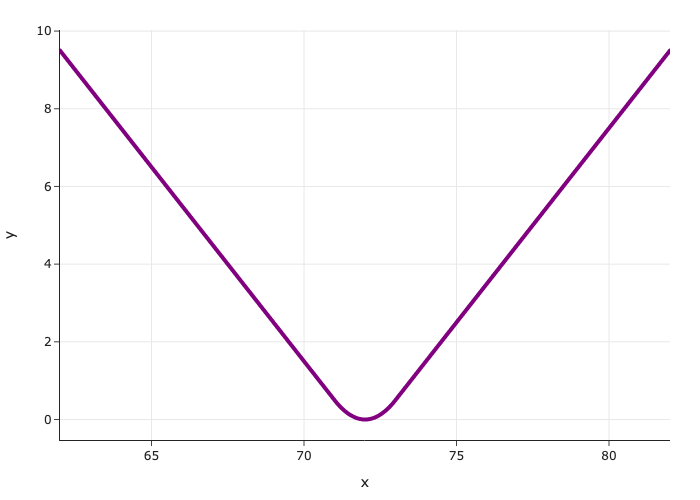

In [21]:
px.line(x=h, y=Rh).update_traces(line_color='purple', line_width=4)

In [22]:
def dR(h, delta):
    out = 0
    for i in range(len(y)):
        if np.abs(y[i] - h) <= delta:
            out += -(y[i] - h)
        else:
            out += -delta * (1 if (y[i] - h > 0) else -1)
    return out / len(y)

In [32]:
h = 0
alpha = 5

while np.abs(dR(h, delta=1)) >= 0.001:
    print(round(h, 4), round(dR(h, delta=1), 4))
    h = h - alpha * dR(h, delta=1) # Gradient descent update rule.

0 -1.0
5.0 -1.0
10.0 -1.0
15.0 -1.0
20.0 -1.0
25.0 -1.0
30.0 -1.0
35.0 -1.0
40.0 -1.0
45.0 -1.0
50.0 -1.0
55.0 -1.0
60.0 -1.0
65.0 -0.6
68.0 -0.6
71.0 -0.6
74.0 -0.2
75.0 -0.2
76.0 -0.2
77.0 -0.2
78.0 -0.2
79.0 -0.2
80.0 -0.2
81.0 -0.2
82.0 -0.2
83.0 -0.2
84.0 -0.2


For a larger dataset:

In [23]:
y = np.array([72, 90, 61, 85, 92])

In [24]:
h = np.linspace(np.min(y) - 10, np.max(y) + 15, 10000)
Rh = [R(hi, delta=1) for hi in h]

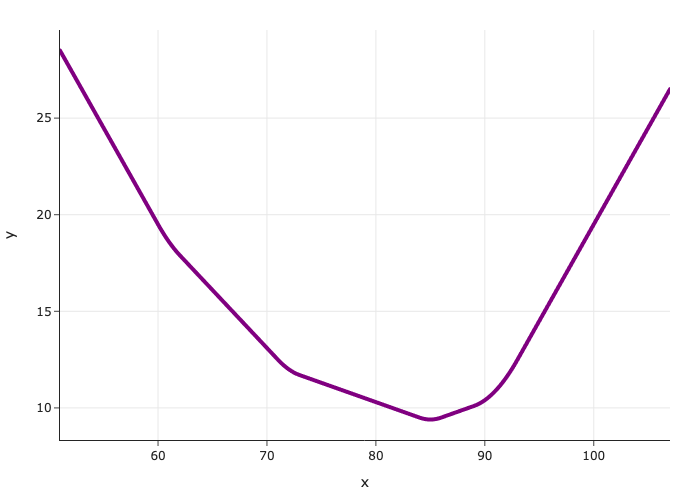

In [25]:
px.line(x=h, y=Rh).update_traces(line_color='purple', line_width=4)

$$L_\text{huber}(y_i, h) = \begin{cases} \frac{1}{2} (y_i - h)^2 & \text{if } | y_i - h| \leq \delta \\ \delta \cdot (| y_i - h | - \frac{1}{2} \delta) & \text{otherwise} \end{cases}$$

$$\implies \frac{\partial L}{\partial h}(h) = \begin{cases} -(y_i - h)  & \text{if } | y_i - h| \leq \delta \\ -\delta \cdot \text{sign}(y_i - h) & \text{otherwise} \end{cases}$$

$$\implies \frac{dR_\text{huber}}{dh}(h) = \frac{1}{n} \sum_{i = 1}^n \begin{cases} -(y_i - h)  & \text{if } | y_i - h| \leq \delta \\ -\delta \cdot \text{sign}(y_i - h) & \text{otherwise} \end{cases}$$


Now, let's use gradient descent to minimize. Let's use an initial guess of $h_0 = 25$ and $\alpha = 10$:

In [ ]:
def dR(h, delta):
    out = 0
    for i in range(len(y)):
        if np.abs(y[i] - h) <= delta:
            out += -(y[i] - h)
        else:
            out += -delta * (1 if (y[i] - h > 0) else -1)
    return out / len(y)

In [ ]:
h = 0
alpha = 5
while np.abs(dR(h, delta=1)) >= 0.001:
    h = h - alpha * dR(h, delta=1)
    print(round(h, 4), round(dR(h, delta=1), 4))

In [ ]:
minimize_f(dR, t0=25, alpha=10)